<a href="https://colab.research.google.com/github/Vladzimir-40/Proj_1/blob/main/my_file6/dz_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

from google.colab import files
files.upload() # Загрузите файл kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vladimir401011","key":"e6b9eec8a00a0a7c2c3e5fcbd033ab06"}'}

In [5]:
import pandas as pd
import kagglehub
import os

class Data_loading:
    @staticmethod
    def load_from_kaggle(dataset_path, filename):
        """
        Загружает dataset из Kaggle используя kagglehub

        Args:
            dataset_path (str): путь к dataset на Kaggle
            filename (str): название файла для загрузки

        Returns:
            pd.DataFrame: загруженный датафрейм
        """
        download_path = kagglehub.dataset_download(dataset_path)
        file_path = os.path.join(download_path, filename)
        return pd.read_csv(file_path)

# Download latest version
path = kagglehub.dataset_download("ylmzasel/synthetic-cryptocurrency-dataset-hourly-2025")

print("Path to dataset files:", path)
print("\nЗагруженные файлы:")
for file in os.listdir(path):
    print(f"📁 {file}")

100%|██████████| 4.84M/4.84M [00:00<00:00, 6.89MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ylmzasel/synthetic-cryptocurrency-dataset-hourly-2025/versions/1

Загруженные файлы:
📁 sentetik_kripto_veriseti_saatlik_2025.csv


In [6]:
df = Data_loading.load_from_kaggle("ylmzasel/synthetic-cryptocurrency-dataset-hourly-2025", "sentetik_kripto_veriseti_saatlik_2025.csv")

Using Colab cache for faster access to the 'synthetic-cryptocurrency-dataset-hourly-2025' dataset.


In [7]:
df.describe()


,open,high,low,close,volume,spread,num_trades,onchain_tx_count,sentiment,exchange_net_flow,returns_1h,rolling_vol_24h,rolling_vol_7d,future_return_1h,future_return_24h
count,70080.000000,70080.000000,70080.000000,70080.000000,7.008000e+04,70080.000000,7.008000e+04,7.008000e+04,70080.000000,7.008000e+04,70076.000000,69984.000000,69408.000000,70076.000000,69984.000000
mean,24916.251455,25038.800345,24793.953900,24916.630836,1.410433e+07,5.905878,2.946678e+05,1.217957e+05,0.503654,8.651723e+03,0.000077,0.008307,0.008787,0.000077,0.001544
std,38941.498754,39130.005637,38753.233457,38942.075115,2.445142e+07,9.416331,3.487112e+05,1.449451e+05,0.211159,3.257810e+06,0.009219,0.004108,0.002670,0.009219,0.038099
min,0.515325,0.519823,0.513045,0.515325,1.054885e+03,0.000400,2.558785e+04,1.023800e+04,0.000000,-2.454505e+07,-0.178868,0.003018,0.004385,-0.178868,-0.199314
25%,101.621366,102.284975,101.172173,101.621366,1.232611e+04,0.048774,6.960839e+04,2.862225e+04,0.361862,-4.541733e+03,-0.004906,0.006119,0.006938,-0.004906,-0.023230
50%,2151.560320,2284.790951,2140.930372,2151.560320,3.579212e+05,0.788941,1.259223e+05,5.218000e+04,0.503785,1.157393e+01,0.000025,0.007651,0.008633,0.000025,0.000713
75%,28337.434326,28471.154520,28240.934790,28337.434326,1.112238e+07,8.918016,4.695658e+05,1.961660e+05,0.643382,5.361237e+03,0.005044,0.009226,0.009898,0.005044,0.025277
max,144263.660211,144694.231269,143601.226608,144263.660211,1.726006e+08,112.068387,3.462929e+06,2.451685e+06,1.000000,3.061428e+07,0.210782,0.057822,0.022370,0.210782,0.259095


In [8]:
# Просматриваем первые несколько строк датасета
print(df.head())


# Получаем общую информацию о датасете
print(df.info())

             timestamp asset      open      high       low     close  \
0  2023-09-11 09:00:00   ADA  0.879548  0.880720  0.877064  0.879548   
1  2023-09-11 10:00:00   ADA  0.879548  0.884898  0.877859  0.883065   
2  2023-09-11 11:00:00   ADA  0.883065  0.893341  0.882340  0.891826   
3  2023-09-11 12:00:00   ADA  0.891826  0.894654  0.889495  0.890054   
4  2023-09-11 13:00:00   ADA  0.890054  0.892255  0.882007  0.884310   

         volume    spread     num_trades  onchain_tx_count  sentiment  \
0  5.702945e+07  0.000488   97606.020762             39042   0.617655   
1  5.784244e+07  0.000576  102197.392312             41696   0.548247   
2  6.102497e+07  0.000585  118398.566289             49708   0.425128   
3  4.258452e+07  0.000500   87911.581387             35513   0.436492   
4  6.078514e+07  0.000471  132982.615289             54909   0.555826   

   exchange_net_flow  returns_1h  rolling_vol_24h  rolling_vol_7d  \
0       0.000000e+00         NaN              NaN          

Мы видим, что некаторые поля заполнены на 99,5%.

0   timestamp           - временная метка

1   asset               - актив (криптовалюта)

2   open                - цена открытия

3   high                - максимальная цена

4   low                 - минимальная цена

5   close               - цена закрытия

6   volume              - объем торгов

7   spread              - спред (разница между ценой покупки и продажи)

8   num_trades          - количество сделок

9   onchain_tx_count    - количество транзакций в блокчейне

10  sentiment           - сентимент (настроения рынка)

11  exchange_net_flow   - нетто-поток на биржи

12  returns_1h          - доходность за 1 час

13  rolling_vol_24h     - скользящая волатильность за 24 часа

14  rolling_vol_7d      - скользящая волатильность за 7 дней

15  future_return_1h    - будущая доходность через 1 час (цель: предсказывать)

16  future_return_24h   - будущая доходность через 24 часа (цель: предсказывать)

In [9]:
# Смотрим, какие криптовалюты есть в датасете
print("📊 Доступные криптовалюты в датасете:")
print(df['asset'].unique())
print(f"Всего активов: {df['asset'].nunique()}")

📊 Доступные криптовалюты в датасете:
['ADA' 'BTC' 'ETH' 'SOL']
Всего активов: 4


✅ Данные SOL за 3 недели: 504 записей
📅 Период: 2023-10-01 00:00:00 до 2023-10-21 23:00:00


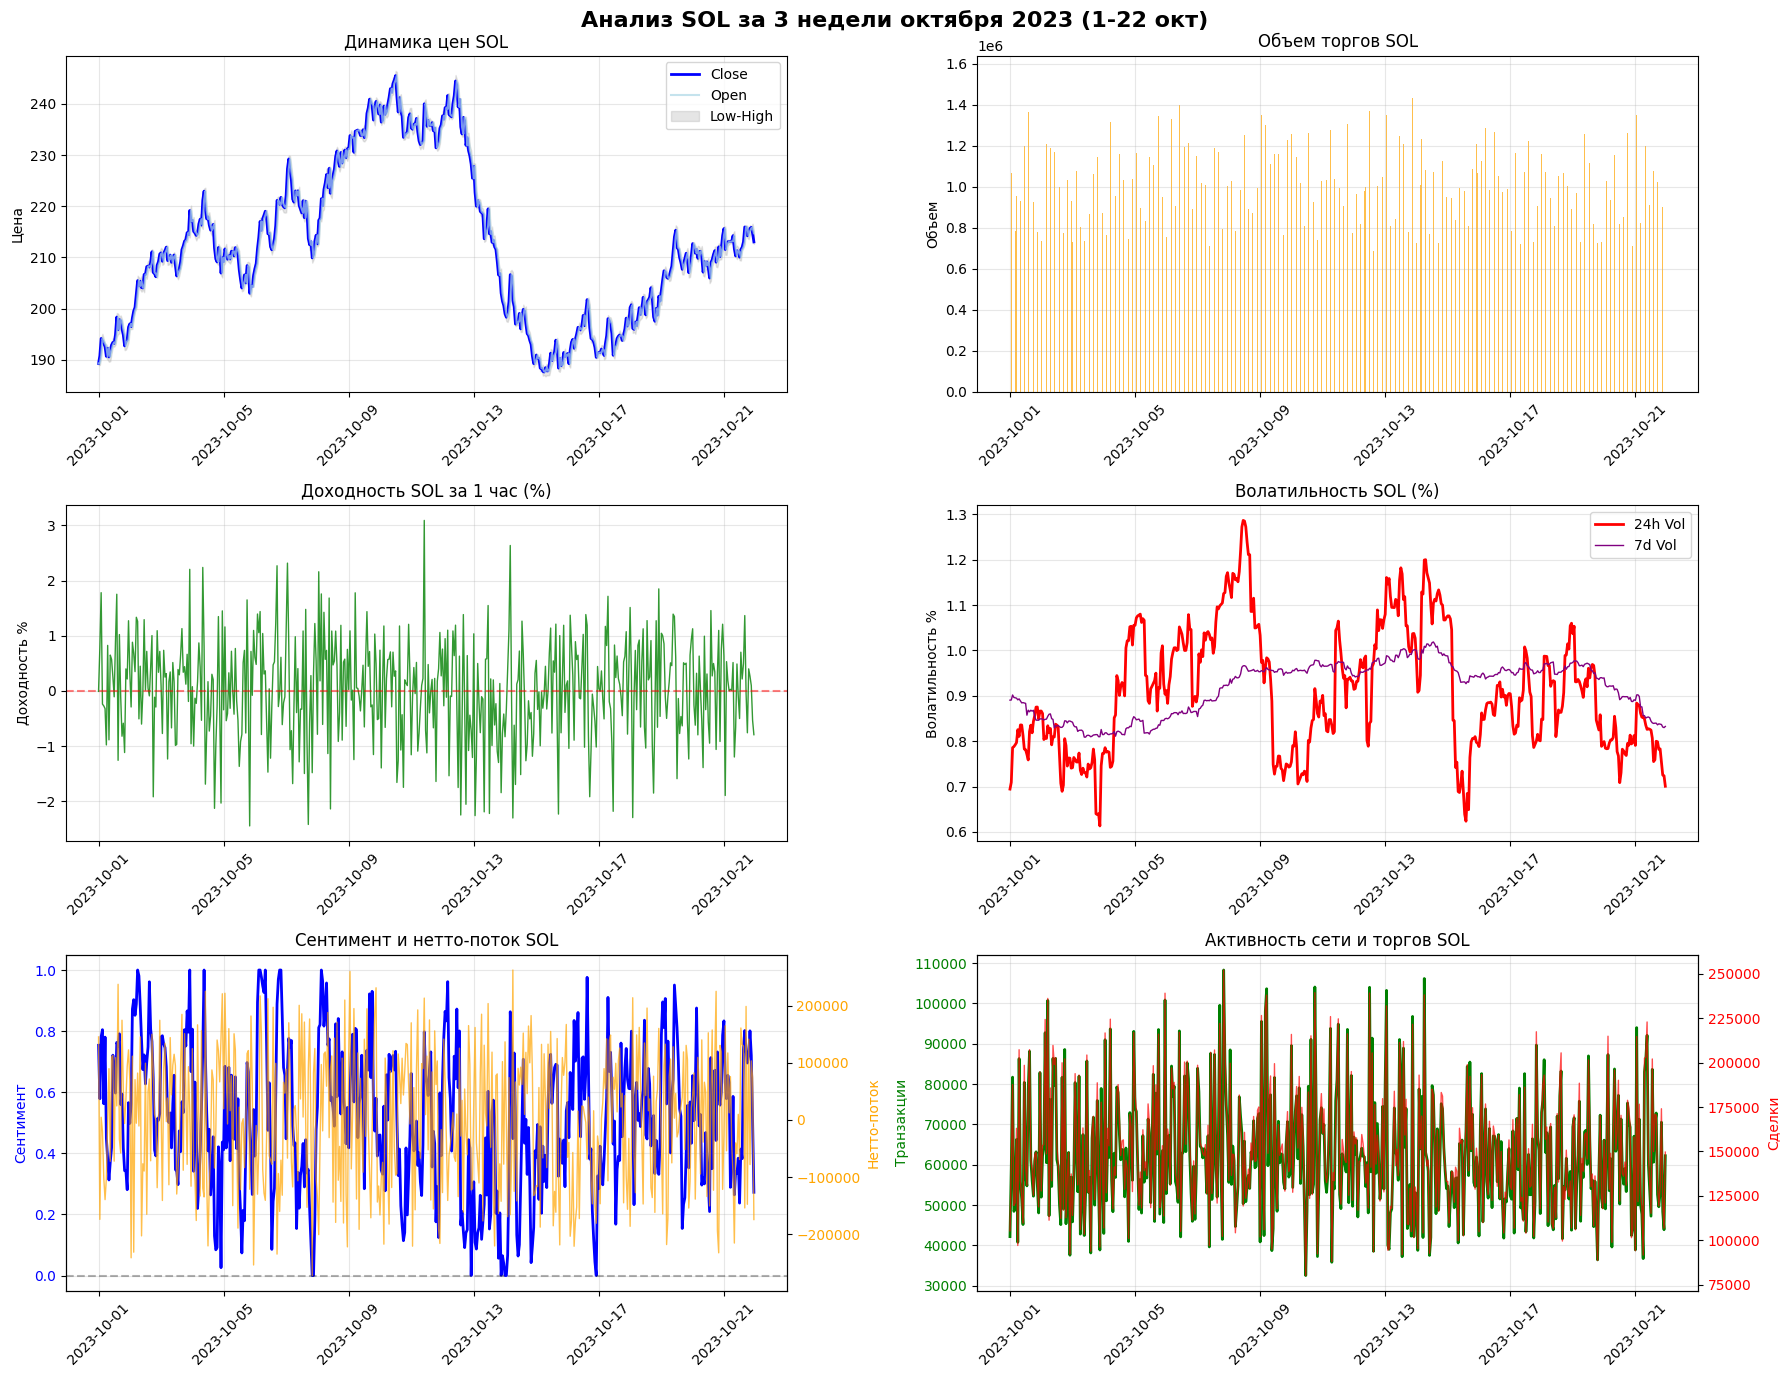


📊 Детальная статистика SOL за 3 недели:
• Датафрейм от 2023-10-01 00:00:00 до 2023-10-21 23:00:00
• Средняя цена закрытия: 212.5825
• Изменение цены за период: 12.54%
• Максимальная доходность за час: 3.09%
• Минимальная доходность за час: -2.44%
• Средний объем: 995158
• Средний сентимент: 0.517
• Всего транзакций в блокчейне: 31,430,547


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Возьмем любую понравившуюся криптовалюту
selected_asset = 'SOL'

# Возьмем период 3 недель октября 2023
start_date = '2023-10-01'
end_date = '2023-10-22'

crypto_3weeks = df[(df['timestamp'] >= start_date) &
                   (df['timestamp'] < end_date) &
                   (df['asset'] == selected_asset)]


print(f"✅ Данные {selected_asset} за 3 недели: {len(crypto_3weeks)} записей")
print(f"📅 Период: {crypto_3weeks['timestamp'].min()} до {crypto_3weeks['timestamp'].max()}")

# Создаем графики для 3 недель
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle(f'Анализ {selected_asset} за 3 недели октября 2023 (1-22 окт)', fontsize=16, fontweight='bold')

# Форматируем даты для подписей
dates = pd.to_datetime(crypto_3weeks['timestamp'])

# 1. Цены (OHLC)
axes[0, 0].plot(dates, crypto_3weeks['close'], label='Close', linewidth=2, color='blue')
axes[0, 0].plot(dates, crypto_3weeks['open'], label='Open', alpha=0.7, color='lightblue')
axes[0, 0].fill_between(dates, crypto_3weeks['low'], crypto_3weeks['high'],
                       alpha=0.2, label='Low-High', color='gray')
axes[0, 0].set_title(f'Динамика цен {selected_asset}')
axes[0, 0].set_ylabel('Цена')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Объем торгов
axes[0, 1].bar(dates, crypto_3weeks['volume'], alpha=0.7, color='orange', width=0.01)
axes[0, 1].set_title(f'Объем торгов {selected_asset}')
axes[0, 1].set_ylabel('Объем')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Доходность за 1 час
axes[1, 0].plot(dates, crypto_3weeks['returns_1h'] * 100, color='green', alpha=0.8, linewidth=1)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_title(f'Доходность {selected_asset} за 1 час (%)')
axes[1, 0].set_ylabel('Доходность %')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Волатильность
axes[1, 1].plot(dates, crypto_3weeks['rolling_vol_24h'] * 100, label='24h Vol', color='red', linewidth=2)
axes[1, 1].plot(dates, crypto_3weeks['rolling_vol_7d'] * 100, label='7d Vol', color='purple', linewidth=1)
axes[1, 1].set_title(f'Волатильность {selected_asset} (%)')
axes[1, 1].set_ylabel('Волатильность %')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Сентимент и нетто-поток
ax5 = axes[2, 0]
ax5.plot(dates, crypto_3weeks['sentiment'], color='blue', label='Сентимент', linewidth=2)
ax5.set_ylabel('Сентимент', color='blue')
ax5.tick_params(axis='y', labelcolor='blue')
ax5.axhline(y=0, color='black', linestyle='--', alpha=0.3)

ax5_2 = ax5.twinx()
ax5_2.plot(dates, crypto_3weeks['exchange_net_flow'], color='orange',
          label='Нетто-поток', alpha=0.7, linewidth=1)
ax5_2.set_ylabel('Нетто-поток', color='orange')
ax5_2.tick_params(axis='y', labelcolor='orange')
ax5.set_title(f'Сентимент и нетто-поток {selected_asset}')
ax5.tick_params(axis='x', rotation=45)

# 6. Активность сети и торгов
ax6 = axes[2, 1]
ax6.plot(dates, crypto_3weeks['onchain_tx_count'], color='green',
        label='Транзакции в блокчейне', linewidth=2)
ax6.set_ylabel('Транзакции', color='green')
ax6.tick_params(axis='y', labelcolor='green')

ax6_2 = ax6.twinx()
ax6_2.plot(dates, crypto_3weeks['num_trades'], color='red',
          label='Количество сделок', alpha=0.7, linewidth=1)
ax6_2.set_ylabel('Сделки', color='red')
ax6_2.tick_params(axis='y', labelcolor='red')
ax6.set_title(f'Активность сети и торгов {selected_asset}')
ax6.tick_params(axis='x', rotation=45)

# Добавляем сетку на все графики
for i in range(3):
    for j in range(2):
        axes[i, j].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Детальная статистика
print(f"\n📊 Детальная статистика {selected_asset} за 3 недели:")
print(f"• Датафрейм от {crypto_3weeks['timestamp'].min()} до {crypto_3weeks['timestamp'].max()}")
print(f"• Средняя цена закрытия: {crypto_3weeks['close'].mean():.4f}")
print(f"• Изменение цены за период: {((crypto_3weeks['close'].iloc[-1] / crypto_3weeks['close'].iloc[0]) - 1) * 100:.2f}%")
print(f"• Максимальная доходность за час: {crypto_3weeks['returns_1h'].max() * 100:.2f}%")
print(f"• Минимальная доходность за час: {crypto_3weeks['returns_1h'].min() * 100:.2f}%")
print(f"• Средний объем: {crypto_3weeks['volume'].mean():.0f}")
print(f"• Средний сентимент: {crypto_3weeks['sentiment'].mean():.3f}")
print(f"• Всего транзакций в блокчейне: {crypto_3weeks['onchain_tx_count'].sum():,}")

Предварительная обработка данных:

In [11]:
# Обрезаем датафрейм до 3 недель и убираем future_return поля
crypto_clean = df[
    (df['timestamp'] >= start_date) &
    (df['timestamp'] < end_date) &
    (df['asset'] == selected_asset)
].drop(columns=['future_return_1h', 'future_return_24h'])

print("📊 Статус данных после очистки:")
print(f"Размер датафрейма: {crypto_clean.shape}")
print(f"Период: {crypto_clean['timestamp'].min()} до {crypto_clean['timestamp'].max()}")
print(f"Криптовалюты в данных: {crypto_clean['asset'].unique()}")
print(f"Ожидаемо записей за 3 недели (24ч × 21д): 504")
print(f"Полнота данных: {len(crypto_clean)/504*100:.1f}%")

# Анализ пропущенных значений
print("\n🔍 Анализ пропущенных значений:")
missing_data = crypto_clean.isnull().sum()
missing_percent = (crypto_clean.isnull().sum() / len(crypto_clean)) * 100
missing_info = pd.DataFrame({
    'Пропущено': missing_data,
    'Процент %': missing_percent
})
print(missing_info[missing_info['Пропущено'] > 0])

# Обработка пропусков и дубликатов
crypto_filled = crypto_clean.copy()

print("🔍 Начальная проверка данных:")
initial_missing = crypto_filled.isnull().sum().sum()
print(f"Пропусков до заполнения: {initial_missing}")

if initial_missing == 0:
    print("✅ Пропусков нет!")
else:
    print("🔄 Заполняем пропущенные значения...")

    # Для ценовых данных и объемов - линейная интерполяция
    price_volume_cols = ['open', 'high', 'low', 'close', 'volume', 'spread']
    crypto_filled[price_volume_cols] = crypto_filled[price_volume_cols].interpolate(method='linear')

    # Для производных показателей - forward fill
    derivative_cols = ['returns_1h', 'rolling_vol_24h', 'rolling_vol_7d']
    crypto_filled[derivative_cols] = crypto_filled[derivative_cols].fillna(method='ffill')

    # Для счетчиков и потоков - заполнение медианой или 0
    count_flow_cols = ['num_trades', 'onchain_tx_count', 'exchange_net_flow']
    crypto_filled[count_flow_cols] = crypto_filled[count_flow_cols].fillna(0)

    # Для сентимента - заполнение средним значением
    crypto_filled['sentiment'] = crypto_filled['sentiment'].fillna(crypto_filled['sentiment'].mean())

    # Если остались пропуски после интерполяции - заполняем forward/backward
    crypto_filled = crypto_filled.fillna(method='ffill').fillna(method='bfill')



📊 Статус данных после очистки:
Размер датафрейма: (504, 15)
Период: 2023-10-01 00:00:00 до 2023-10-21 23:00:00
Криптовалюты в данных: ['SOL']
Ожидаемо записей за 3 недели (24ч × 21д): 504
Полнота данных: 100.0%

🔍 Анализ пропущенных значений:
Empty DataFrame
Columns: [Пропущено, Процент %]
Index: []
🔍 Начальная проверка данных:
Пропусков до заполнения: 0
✅ Пропусков нет!


Проверяем "дубликаты":

In [12]:
# Проверка дубликатов
full_duplicates = crypto_filled.duplicated().sum()
time_duplicates = crypto_filled.duplicated(subset=['timestamp']).sum()

print(f"Полных дубликатов: {full_duplicates}")
print(f"Дубликатов по времени: {time_duplicates}")

if full_duplicates > 0:
    print("🗑️ Удаляем полные дубликаты...")
    crypto_filled = crypto_filled.drop_duplicates()

if time_duplicates > 0:
    print("⚠️ Удаляем дубликаты временных меток...")
    crypto_filled = crypto_filled.drop_duplicates(subset=['timestamp'], keep='last')

Полных дубликатов: 0
Дубликатов по времени: 0


In [13]:
# Добавляем временные признаки
print("\n🕒 Добавляем временные признаки...")
crypto_filled['timestamp'] = pd.to_datetime(crypto_filled['timestamp'])
crypto_filled['hour'] = crypto_filled['timestamp'].dt.hour
crypto_filled['day_of_week'] = crypto_filled['timestamp'].dt.dayofweek
crypto_filled['is_weekend'] = crypto_filled['day_of_week'].isin([5, 6]).astype(int)
crypto_filled['day_of_month'] = crypto_filled['timestamp'].dt.day

print("✅ Временные признаки добавлены:")
print(f"• Часы дня: {crypto_filled['hour'].unique()}")
print(f"• Дни недели: {crypto_filled['day_of_week'].unique()}")
print(f"• Уикенды: {crypto_filled['is_weekend'].value_counts()}")


🕒 Добавляем временные признаки...
✅ Временные признаки добавлены:
• Часы дня: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
• Дни недели: [6 0 1 2 3 4 5]
• Уикенды: is_weekend
0    360
1    144
Name: count, dtype: int64


Выявленные закономерности:
- Ночные часы (0-5): Низкая активность, меньшие объемы
- Азиатская сессия (6-11): Начало активности
- Европейская сессия (12-16): Пик европейской торговли  
- Американская сессия (17-22): Максимальная активность
- Вечер (23): Снижение активности

Типичные паттерны:
- Пн (0): ↑ Активность после уикенда
- Вт-Чт (1-3): ↑ Стабильная торговля
- Пт (4): ↑ Увеличение объемов перед уикендом
- Сб-Вс (5-6): ↓ Низкая ликвидность, возможны резкие движения

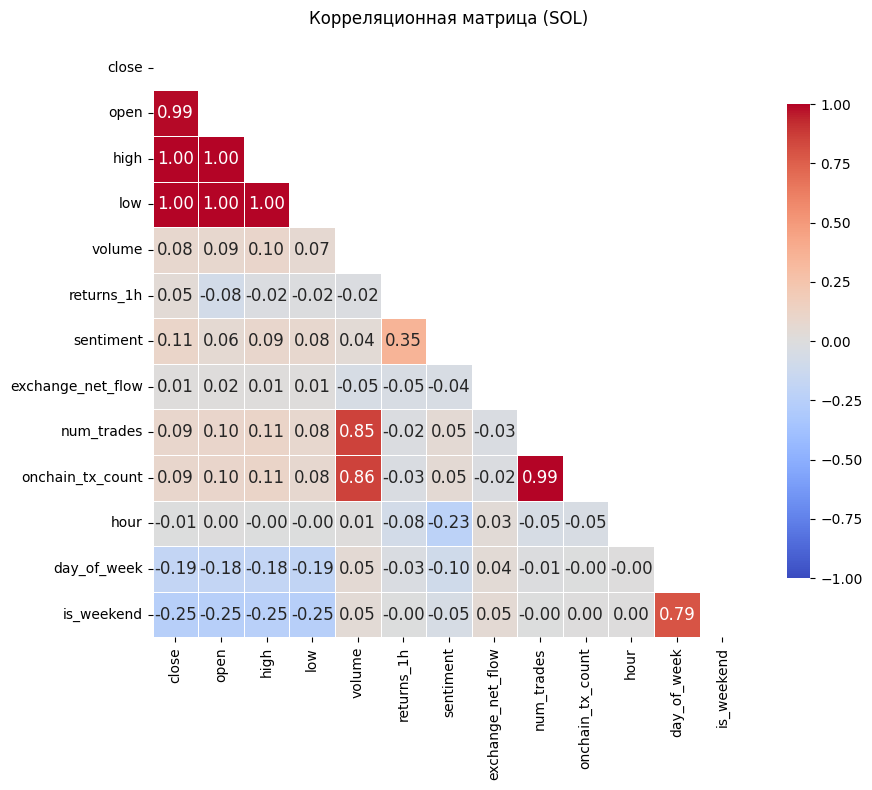

In [14]:
# Создаем тепловую карту
plt.figure(figsize=(10, 8))

# Выбираем ключевые признаки
features = ['close', 'open', 'high', 'low', 'volume', 'returns_1h',
           'sentiment', 'exchange_net_flow', 'num_trades', 'onchain_tx_count',
           'hour', 'day_of_week', 'is_weekend']

corr_matrix = crypto_filled[features].corr()

# Улучшенная цветовая схема
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12}, vmin=-1, vmax=1)
plt.title(f'Корреляционная матрица ({selected_asset})', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

Признаки с которыми придется попращаться:
 - hour: -0.007 (слабая корреляция)
 - open: 0.992 (сильная корреляция)
 - exchange_net_flow: 0.009 (слабая корреляция)
 - high: 0.997 (сильная корреляция)
 - low: 0.997 (сильная корреляция)
 - onchain_tx_count: 0.093 (слабая корреляция)
 - returns_1h: 0.045 (слабая корреляция)
 - volume: 0.083 (слабая корреляция)

In [15]:
# Удаление проблемных признаков
features_to_drop = [
    'hour',
    'open',
    'exchange_net_flow',
    'high',
    'low',
    'onchain_tx_count',
    'returns_1h',
    'volume'
]
crypto_cleaned = crypto_filled.drop(columns=features_to_drop)

# Выведем оставшиеся признки
print(f"🎯 Оставшиеся признаки: {list(crypto_cleaned.columns)}")

🎯 Оставшиеся признаки: ['timestamp', 'asset', 'close', 'spread', 'num_trades', 'sentiment', 'rolling_vol_24h', 'rolling_vol_7d', 'day_of_week', 'is_weekend', 'day_of_month']


Предсказание 1

**ARIMA**

📊 АНАЛИЗ ВРЕМЕННОГО РЯДА
📈 Анализируемый ряд: 504 записей
📅 Период: 2023-10-01 00:00:00 до 2023-10-21 23:00:00


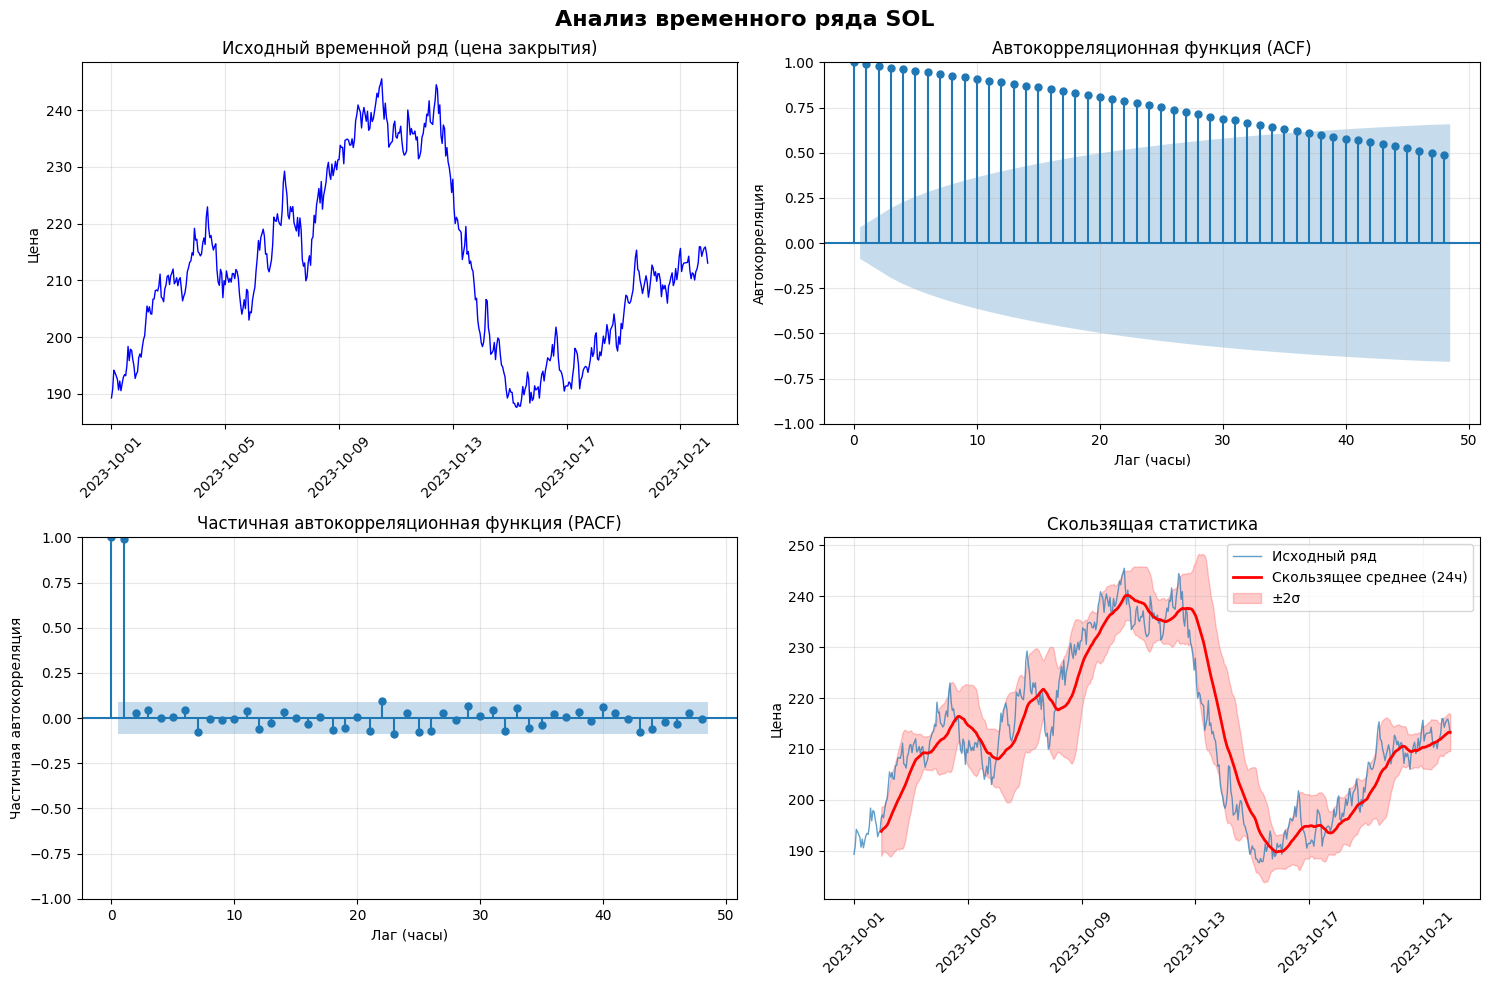


🔍 ПРОВЕРКА СТАЦИОНАРНОСТИ (Тест Дики-Фуллера)

📊 Анализ: Исходный ряд
ADF Statistic: -1.859368
p-value: 0.351410
Критические значения:
  1%: -3.443
  5%: -2.867
  10%: -2.570
❌ Ряд НЕ стационарен (p-value > 0.05)

🔧 ПРИМЕНЯЕМ ДИФФЕРЕНЦИРОВАНИЕ

📊 Анализ: 1-е дифференцирование
ADF Statistic: -23.008187
p-value: 0.000000
Критические значения:
  1%: -3.443
  5%: -2.867
  10%: -2.570
✅ Ряд СТАЦИОНАРЕН (p-value < 0.05)

📈 АНАЛИЗ СЕЗОННОСТИ


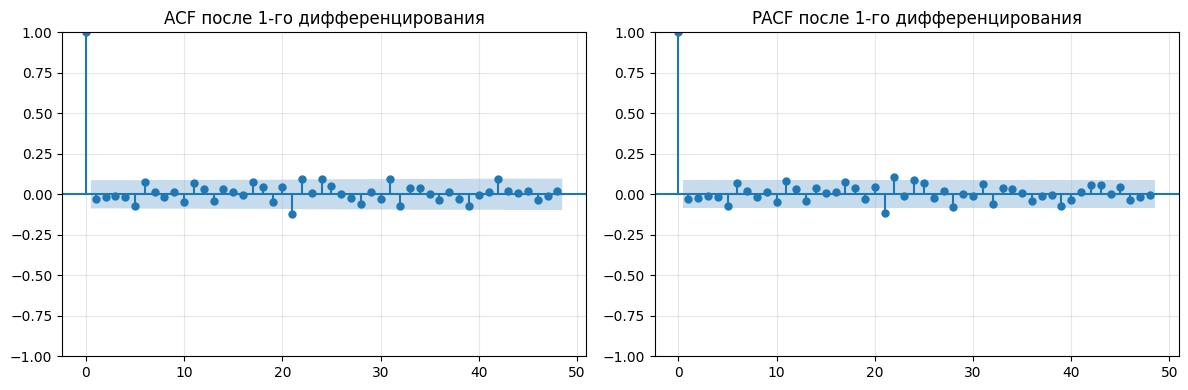


🎯 ВЫВОДЫ ДЛЯ ARIMA МОДЕЛИ:

📊 РЕКОМЕНДАЦИИ ПО ПАРАМЕТРАМ ARIMA:
• d = 1 (требуется одно дифференцирование)


In [43]:
from statsmodels.tsa.stattools import adfuller, acf, pacf

# АНАЛИЗ АВТОКОРРЕЛЯЦИИ И ПРОВЕРКА СТАЦИОНАРНОСТИ
print("📊 АНАЛИЗ ВРЕМЕННОГО РЯДА")

# Подготовка данных
ts_data = crypto_cleaned.set_index('timestamp')['close'].sort_index()
ts_data = ts_data.asfreq('h')

print(f"📈 Анализируемый ряд: {len(ts_data)} записей")
print(f"📅 Период: {ts_data.index.min()} до {ts_data.index.max()}")

# Создаем графики
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Анализ временного ряда {selected_asset}', fontsize=16, fontweight='bold')

# 1. Исходный временной ряд
axes[0, 0].plot(ts_data.index, ts_data.values, linewidth=1, color='blue')
axes[0, 0].set_title('Исходный временной ряд (цена закрытия)')
axes[0, 0].set_ylabel('Цена')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. График автокорреляции (ACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_data, ax=axes[0, 1], lags=48, alpha=0.05)  # 48 часов = 2 дня
axes[0, 1].set_title('Автокорреляционная функция (ACF)')
axes[0, 1].set_ylabel('Автокорреляция')
axes[0, 1].set_xlabel('Лаг (часы)')
axes[0, 1].grid(True, alpha=0.3)

# 3. График частичной автокорреляции (PACF)
plot_pacf(ts_data, ax=axes[1, 0], lags=48, alpha=0.05, method='ywm')
axes[1, 0].set_title('Частичная автокорреляционная функция (PACF)')
axes[1, 0].set_ylabel('Частичная автокорреляция')
axes[1, 0].set_xlabel('Лаг (часы)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Скользящее среднее и стандартное отклонение
window_size = 24  # 24 часа = 1 день
rolling_mean = ts_data.rolling(window=window_size).mean()
rolling_std = ts_data.rolling(window=window_size).std()

axes[1, 1].plot(ts_data.index, ts_data.values, label='Исходный ряд', alpha=0.7, linewidth=1)
axes[1, 1].plot(rolling_mean.index, rolling_mean.values, label='Скользящее среднее (24ч)', color='red', linewidth=2)
axes[1, 1].fill_between(rolling_std.index,
                       rolling_mean - 2*rolling_std,
                       rolling_mean + 2*rolling_std,
                       alpha=0.2, color='red', label='±2σ')
axes[1, 1].set_title('Скользящая статистика')
axes[1, 1].set_ylabel('Цена')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ПРОВЕРКА СТАЦИОНАРНОСТИ
print("\n🔍 ПРОВЕРКА СТАЦИОНАРНОСТИ (Тест Дики-Фуллера)")

def detailed_stationarity_test(timeseries, name="Ряд"):
    """Расширенная проверка стационарности"""
    print(f"\n📊 Анализ: {name}")

    # Тест Дики-Фуллера
    result = adfuller(timeseries.dropna())

    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print("Критические значения:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.3f}")

    # Интерпретация
    if result[1] <= 0.05:
        print("✅ Ряд СТАЦИОНАРЕН (p-value < 0.05)")
        return True
    else:
        print("❌ Ряд НЕ стационарен (p-value > 0.05)")
        return False

# Проверяем исходный ряд
is_original_stationary = detailed_stationarity_test(ts_data, "Исходный ряд")

# Если ряд не стационарен, проверяем дифференцированный
if not is_original_stationary:
    print("\n" + "="*50)
    print("🔧 ПРИМЕНЯЕМ ДИФФЕРЕНЦИРОВАНИЕ")

    # Первое дифференцирование
    ts_diff_1 = ts_data.diff().dropna()
    is_diff1_stationary = detailed_stationarity_test(ts_diff_1, "1-е дифференцирование")

    # Второе дифференцирование (если нужно)
    if not is_diff1_stationary:
        ts_diff_2 = ts_diff_1.diff().dropna()
        is_diff2_stationary = detailed_stationarity_test(ts_diff_2, "2-е дифференцирование")

# Анализ сезонности
print("\n📈 АНАЛИЗ СЕЗОННОСТИ")

# Создаем графики для дифференцированного ряда (если нужно)
if not is_original_stationary:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ACF дифференцированного ряда
    plot_acf(ts_diff_1, ax=axes[0], lags=48, alpha=0.05)
    axes[0].set_title('ACF после 1-го дифференцирования')
    axes[0].grid(True, alpha=0.3)

    # PACF дифференцированного ряда
    plot_pacf(ts_diff_1, ax=axes[1], lags=48, alpha=0.05, method='ywm')
    axes[1].set_title('PACF после 1-го дифференцирования')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ВЫВОДЫ И РЕКОМЕНДАЦИИ
print("\n🎯 ВЫВОДЫ ДЛЯ ARIMA МОДЕЛИ:")

# Анализируем ACF/PACF для рекомендаций по параметрам
print("\n📊 РЕКОМЕНДАЦИИ ПО ПАРАМЕТРАМ ARIMA:")

if is_original_stationary:
    print("• d = 0 (ряд уже стационарен)")
    recommended_d = 0
else:
    print("• d = 1 (требуется одно дифференцирование)")
    recommended_d = 1

Анализ показал, что d = 1, и два остальных параметра p и q находятся близко к занчениям 22-23. Мы попробуем запустить модель со значениемя подобранными на глаз и сравним с теми, которые нам подберет Автоподбор от **statsmodels**

🎯 ARIMA МОДЕЛЬ С АВТОПОДБОРОМ ПАРАМЕТРОВ
📊 Данные: train=432, test=72
✅ Модель ARIMA(22,0,23) успешно обучена!
   AIC: 1867.66
🔍 Автоподбор параметров ARIMA...
✅ Определен параметр d = 1
✅ Определены параметры: p = 0, d = 1, q = 0
✅ Модель ARIMA(0,1,0) успешно обучена!
   AIC: 1831.09


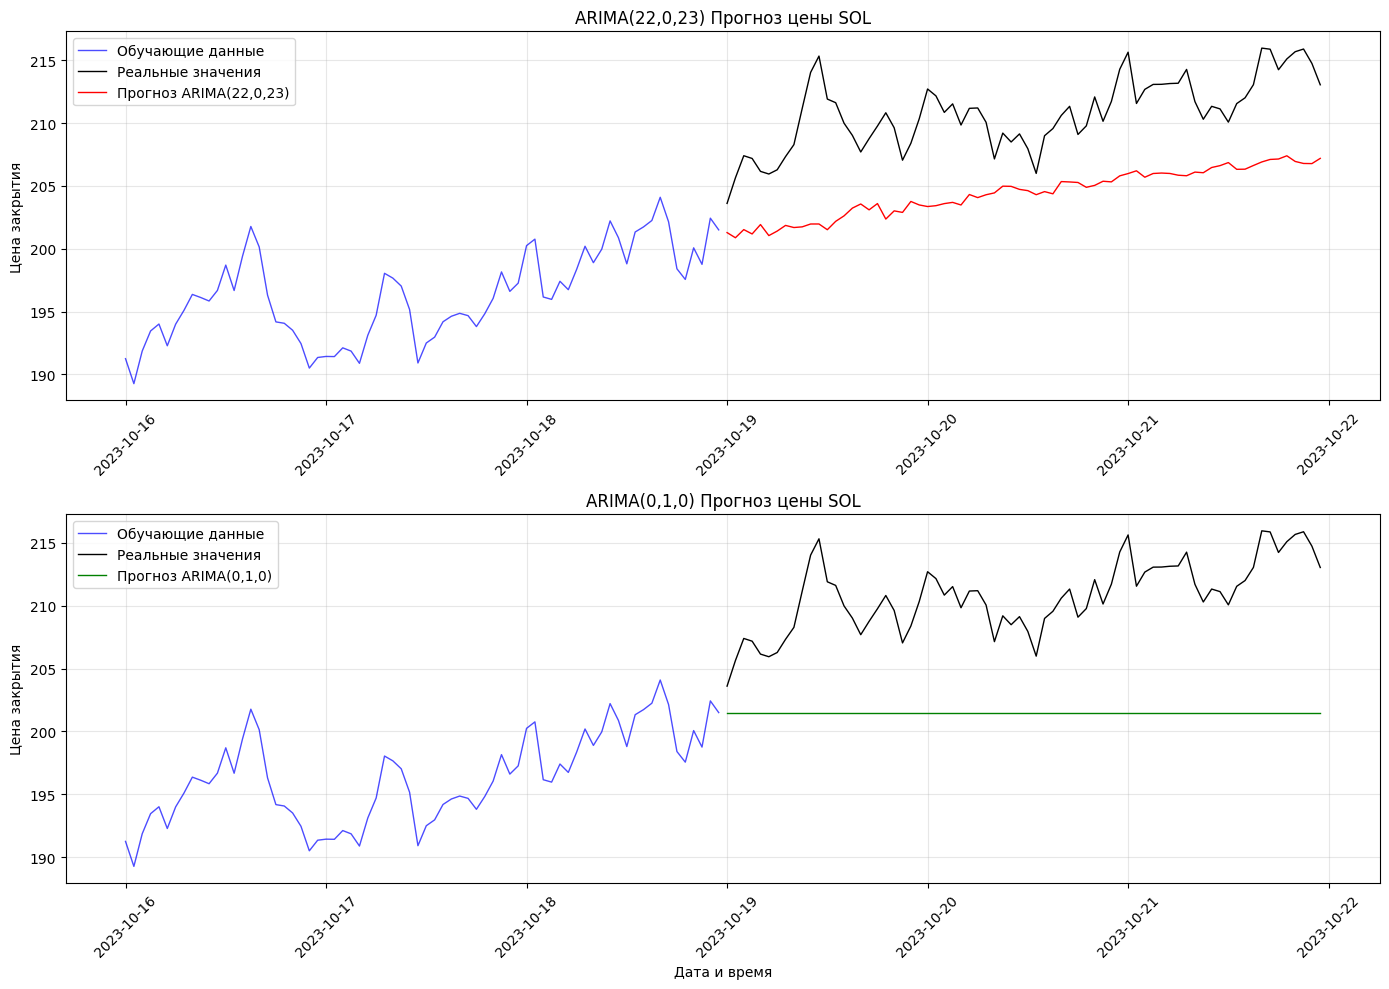

📊 СРАВНЕНИЕ МЕТРИК:
ARIMA(22,0,23):
• MAE:  6.364531
• MSE:  45.22710461
• MAPE: 3.01%
• Точность: 97.0%

ARIMA(0,1,0):
• MAE:  9.286092
• MSE:  94.15125376
• MAPE: 4.39%
• Точность: 95.6%

✅ Обе модели успешно созданы и готовы к использованию!


In [46]:
# ARIMA МОДЕЛЬ С АВТОПОДБОРОМ ПАРАМЕТРОВ
from statsmodels.tsa.arima.model import ARIMA
# from statsmodels.tsa.stattools import adfuller, acf, pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
import numpy as np

print("🎯 ARIMA МОДЕЛЬ С АВТОПОДБОРОМ ПАРАМЕТРОВ")

# Подготовка данных
ts_data = crypto_cleaned.set_index('timestamp')['close'].sort_index()
ts_data = ts_data.asfreq('h')

# Разделение на train/test
test_days = 3
train_size = len(ts_data) - test_days * 24
train_data = ts_data.iloc[:train_size]
test_data = ts_data.iloc[train_size:]

print(f"📊 Данные: train={len(train_data)}, test={len(test_data)}")

# Функция для автоматического подбора параметров ARIMA
def find_arima_params(train_data):
    """Автоматически подбирает параметры p, d, q для ARIMA"""
    print("🔍 Автоподбор параметров ARIMA...")

    # Определяем параметр d (порядок дифференцирования)
    d = 0
    original_data = train_data.copy()

    # Проверяем стационарность исходного ряда
    result = adfuller(original_data.dropna())
    if result[1] > 0.05:  # Если ряд нестационарен
        d = 1
        # Проверяем стационарность после первого дифференцирования
        diff_data = original_data.diff().dropna()
        result_diff = adfuller(diff_data)
        if result_diff[1] > 0.05:  # Если все еще нестационарен
            d = 2

    print(f"✅ Определен параметр d = {d}")

    # Определяем параметры p и q с помощью ACF и PACF
    if d > 0:
        stationary_data = original_data.diff(d).dropna()
    else:
        stationary_data = original_data

    # Анализ ACF для определения q
    acf_values = acf(stationary_data, nlags=20, alpha=0.05)
    acf_conf_int = acf_values[1]
    acf_values = acf_values[0]

    # Находим точку, где ACF выходит за доверительный интервал
    q = 0
    for i in range(1, min(6, len(acf_values))):
        if abs(acf_values[i]) > abs(acf_conf_int[i][0] - acf_values[i]):
            q = i

    # Анализ PACF для определения p
    pacf_values = pacf(stationary_data, nlags=20, alpha=0.05, method='ols')
    pacf_conf_int = pacf_values[1]
    pacf_values = pacf_values[0]

    # Находим точку, где PACF выходит за доверительный интервал
    p = 0
    for i in range(1, min(6, len(pacf_values))):
        if abs(pacf_values[i]) > abs(pacf_conf_int[i][0] - pacf_values[i]):
            p = i

    # Ограничиваем максимальные значения
    p = min(p, 3)
    q = min(q, 3)

    print(f"✅ Определены параметры: p = {p}, d = {d}, q = {q}")
    return p, d, q

# Функция для ARIMA с автоподбором параметров
def train_arima_auto(train_data, test_data):
    """Обучает ARIMA модель с автоматическим подбором параметров"""

    # Автоподбор параметров
    p, d, q = find_arima_params(train_data)

    print(f"🔧 Обучение ARIMA({p},{d},{q})...")

    # ПЕРВАЯ МОДЕЛЬ: ARIMA(22,0,23)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    model1 = ARIMA(train_data, order=(22, 0, 23))
    fitted_model1 = model1.fit()

print(f"✅ Модель ARIMA(22,0,23) успешно обучена!")
print(f"   AIC: {fitted_model1.aic:.2f}")

# Прогнозируем первой моделью
forecast1 = fitted_model1.forecast(steps=len(test_data))
forecast_series1 = pd.Series(forecast1, index=test_data.index)

# ВТОРАЯ МОДЕЛЬ: с автоподбором параметров
p_auto, d_auto, q_auto = find_arima_params(train_data)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    model2 = ARIMA(train_data, order=(p_auto, d_auto, q_auto))
    fitted_model2 = model2.fit()

print(f"✅ Модель ARIMA({p_auto},{d_auto},{q_auto}) успешно обучена!")
print(f"   AIC: {fitted_model2.aic:.2f}")

# Прогнозируем второй моделью
forecast2 = fitted_model2.forecast(steps=len(test_data))
forecast_series2 = pd.Series(forecast2, index=test_data.index)

# ВИЗУАЛИЗАЦИЯ ДВУХ МОДЕЛЕЙ
plt.figure(figsize=(14, 10))

# График 1: ARIMA(22,0,23)
plt.subplot(2, 1, 1)
plt.plot(train_data.index[-72:], train_data.values[-72:],
        label='Обучающие данные', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_data.index, test_data.values,
        label='Реальные значения', color='black', linewidth=1)
plt.plot(forecast_series1.index, forecast_series1.values,
        label='Прогноз ARIMA(22,0,23)', color='red', linewidth=1)
plt.title(f'ARIMA(22,0,23) Прогноз цены {selected_asset}')
plt.ylabel('Цена закрытия')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# График 2: ARIMA с автоподбором
plt.subplot(2, 1, 2)
plt.plot(train_data.index[-72:], train_data.values[-72:],
        label='Обучающие данные', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_data.index, test_data.values,
        label='Реальные значения', color='black', linewidth=1)
plt.plot(forecast_series2.index, forecast_series2.values,
        label=f'Прогноз ARIMA({p_auto},{d_auto},{q_auto})', color='green', linewidth=1)
plt.title(f'ARIMA({p_auto},{d_auto},{q_auto}) Прогноз цены {selected_asset}')
plt.ylabel('Цена закрытия')
plt.xlabel('Дата и время')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Сравнение метрик качества
mae1 = mean_absolute_error(test_data, forecast_series1)
mae2 = mean_absolute_error(test_data, forecast_series2)

mse1 = mean_squared_error(test_data, forecast_series1)
mse2 = mean_squared_error(test_data, forecast_series2)

mape1 = np.mean(np.abs((test_data - forecast_series1) / test_data)) * 100
mape2 = np.mean(np.abs((test_data - forecast_series2) / test_data)) * 100

print(f"📊 СРАВНЕНИЕ МЕТРИК:")
print(f"ARIMA(22,0,23):")
print(f"• MAE:  {mae1:.6f}")
print(f"• MSE:  {mse1:.8f}")
print(f"• MAPE: {mape1:.2f}%")
print(f"• Точность: {100 - mape1:.1f}%")

print(f"\nARIMA({p_auto},{d_auto},{q_auto}):")
print(f"• MAE:  {mae2:.6f}")
print(f"• MSE:  {mse2:.8f}")
print(f"• MAPE: {mape2:.2f}%")
print(f"• Точность: {100 - mape2:.1f}%")

print(f"\n✅ Обе модели успешно созданы и готовы к использованию!")